In [1]:
import pandas as pd

df = pd.read_csv("/content/sample_data/arxiv_data_210930-054931.csv")

print(df.shape)
print(df.columns)
print(df.head())

(56181, 3)
Index(['terms', 'titles', 'abstracts'], dtype='object')
                           terms  \
0                      ['cs.LG']   
1             ['cs.LG', 'cs.AI']   
2  ['cs.LG', 'cs.CR', 'stat.ML']   
3             ['cs.LG', 'cs.CR']   
4                      ['cs.LG']   

                                              titles  \
0  Multi-Level Attention Pooling for Graph Neural...   
1  Decision Forests vs. Deep Networks: Conceptual...   
2  Power up! Robust Graph Convolutional Network v...   
3  Releasing Graph Neural Networks with Different...   
4  Recurrence-Aware Long-Term Cognitive Network f...   

                                           abstracts  
0  Graph neural networks (GNNs) have been widely ...  
1  Deep networks and decision forests (such as ra...  
2  Graph convolutional networks (GCNs) are powerf...  
3  With the increasing popularity of Graph Neural...  
4  Machine learning solutions for pattern classif...  


In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/arxiv_data_210930-054931.csv")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

Shape:
(56181, 3)

Columns:
Index(['terms', 'titles', 'abstracts'], dtype='object')

First 5 rows:
                           terms  \
0                      ['cs.LG']   
1             ['cs.LG', 'cs.AI']   
2  ['cs.LG', 'cs.CR', 'stat.ML']   
3             ['cs.LG', 'cs.CR']   
4                      ['cs.LG']   

                                              titles  \
0  Multi-Level Attention Pooling for Graph Neural...   
1  Decision Forests vs. Deep Networks: Conceptual...   
2  Power up! Robust Graph Convolutional Network v...   
3  Releasing Graph Neural Networks with Different...   
4  Recurrence-Aware Long-Term Cognitive Network f...   

                                           abstracts  
0  Graph neural networks (GNNs) have been widely ...  
1  Deep networks and decision forests (such as ra...  
2  Graph convolutional networks (GCNs) are powerf...  
3  With the increasing popularity of Graph Neural...  
4  Machine learning solutions for pattern classif...  


In [3]:
import pandas as pd

df = pd.read_csv("/content/sample_data/arxiv_data_210930-054931.csv")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(subset=['titles', 'abstracts'], inplace=True)

# Combine title + abstract
df['text'] = df['titles'] + " " + df['abstracts']

print(df.shape)
df.head()

(41127, 4)


,terms,titles,abstracts,text
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...,Multi-Level Attention Pooling for Graph Neural...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...,Decision Forests vs. Deep Networks: Conceptual...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...,Power up! Robust Graph Convolutional Network v...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...,Releasing Graph Neural Networks with Different...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...,Recurrence-Aware Long-Term Cognitive Network f...


In [4]:
domain_map = {
    'cs.LG': 'Machine Learning',
    'stat.ML': 'Machine Learning',
    'cs.CL': 'Natural Language Processing',
    'cs.CV': 'Computer Vision',
    'cs.AI': 'Artificial Intelligence',
    'cs.CR': 'Cybersecurity'
}
import ast

def get_primary_domain(term_string):

    terms = ast.literal_eval(term_string)

    for term in terms:
        if term in domain_map:
            return domain_map[term]

    return "Other"

df['primary_domain'] = df['terms'].apply(get_primary_domain)

print(df['primary_domain'].value_counts())

primary_domain
Computer Vision     21631
Machine Learning    19496
Name: count, dtype: int64


In [5]:
df['abstract_length'] = df['abstracts'].apply(
    lambda x: len(str(x).split())
)

print(df['abstract_length'].describe())

count    41127.000000
mean       171.456975
std         45.950679
min          5.000000
25%        140.000000
50%        169.000000
75%        201.000000
max        498.000000
Name: abstract_length, dtype: float64


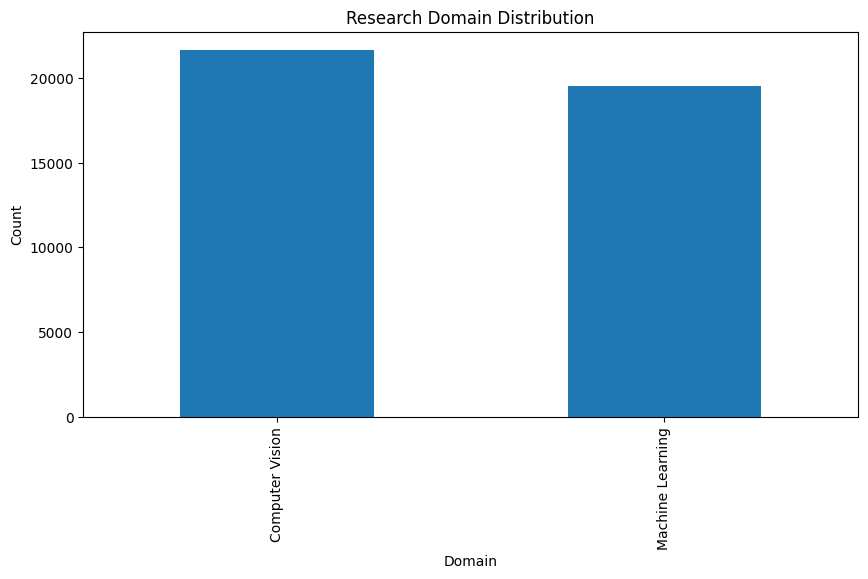

In [6]:
import matplotlib.pyplot as plt

df['primary_domain'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Research Domain Distribution")
plt.xlabel("Domain")
plt.ylabel("Count")

plt.show()

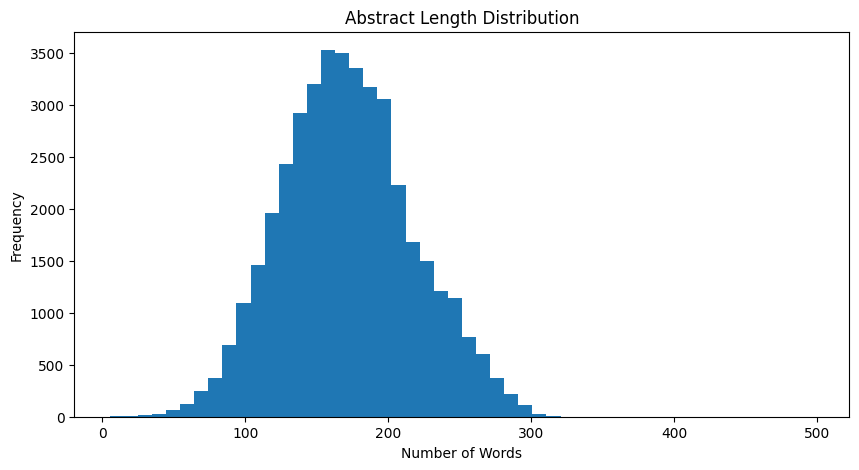

In [7]:
plt.figure(figsize=(10,5))

plt.hist(df['abstract_length'], bins=50)

plt.title("Abstract Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [8]:
df.to_csv("cleaned_arxiv.csv", index=False)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = vectorizer.fit_transform(df['text'])

y = df['primary_domain']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(32901, 5000)
(8226, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
y_pred = lr_model.predict(X_test)

In [13]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

                  precision    recall  f1-score   support

 Computer Vision       0.94      0.93      0.94      4309
Machine Learning       0.92      0.94      0.93      3917

        accuracy                           0.93      8226
       macro avg       0.93      0.93      0.93      8226
    weighted avg       0.93      0.93      0.93      8226



In [14]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

Accuracy: 0.9326525650376853


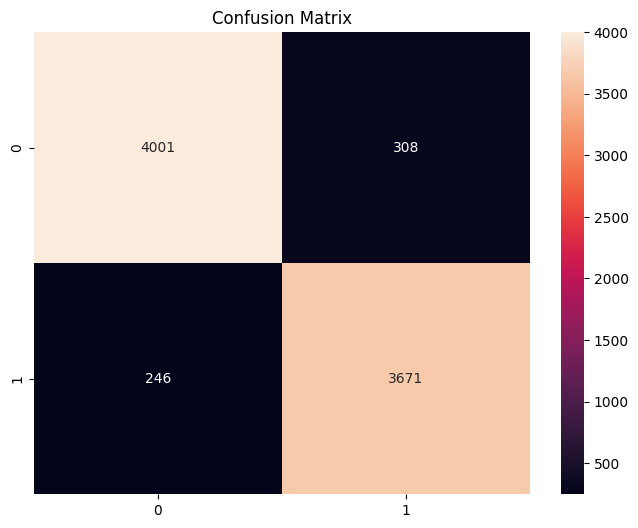

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [16]:
import joblib

joblib.dump(
    lr_model,
    "logistic_regression_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [17]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9326525650376853

Classification Report:

                  precision    recall  f1-score   support

 Computer Vision       0.94      0.93      0.94      4309
Machine Learning       0.92      0.94      0.93      3917

        accuracy                           0.93      8226
       macro avg       0.93      0.93      0.93      8226
    weighted avg       0.93      0.93      0.93      8226



In [18]:
sample_texts = X_test[:5]

preds = lr_model.predict(sample_texts)

print(preds)

['Machine Learning' 'Machine Learning' 'Machine Learning'
 'Computer Vision' 'Computer Vision']


In [19]:
joblib.dump(lr_model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [20]:
print("Classes:", lr_model.classes_)
print("Number of features:", len(vectorizer.get_feature_names_out()))

Classes: ['Computer Vision' 'Machine Learning']
Number of features: 5000


In [21]:
sample_text = df['text'].iloc[0]

vec = vectorizer.transform([sample_text])
pred = lr_model.predict(vec)

print("PREDICTED:", pred[0])
print("ACTUAL:", df['primary_domain'].iloc[0])

PREDICTED: Machine Learning
ACTUAL: Machine Learning


In [22]:
for i in range(5):
    text = df['text'].iloc[i]
    vec = vectorizer.transform([text])
    pred = lr_model.predict(vec)

    print("-----")
    print("ACTUAL:", df['primary_domain'].iloc[i])
    print("PREDICTED:", pred[0])

-----
ACTUAL: Machine Learning
PREDICTED: Machine Learning
-----
ACTUAL: Machine Learning
PREDICTED: Machine Learning
-----
ACTUAL: Machine Learning
PREDICTED: Machine Learning
-----
ACTUAL: Machine Learning
PREDICTED: Machine Learning
-----
ACTUAL: Machine Learning
PREDICTED: Machine Learning


In [23]:
from sklearn.metrics import accuracy_score, classification_report
print("SCIENTIFIC PAPER CLASSIFICATION USING NLP")
print("Model: TF-IDF + Logistic Regression")
print("===== FINAL MODEL RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

SCIENTIFIC PAPER CLASSIFICATION USING NLP
Model: TF-IDF + Logistic Regression
===== FINAL MODEL RESULTS =====
Accuracy: 0.9326525650376853

Classification Report:

                  precision    recall  f1-score   support

 Computer Vision       0.94      0.93      0.94      4309
Machine Learning       0.92      0.94      0.93      3917

        accuracy                           0.93      8226
       macro avg       0.93      0.93      0.93      8226
    weighted avg       0.93      0.93      0.93      8226



In [24]:
import joblib

joblib.dump(lr_model, "final_model.pkl")
joblib.dump(vectorizer, "final_vectorizer.pkl")

['final_vectorizer.pkl']

In [25]:
print("Classes:", lr_model.classes_)

Classes: ['Computer Vision' 'Machine Learning']


In [26]:
print(df.shape)
print(df['primary_domain'].value_counts().head())

(41127, 6)
primary_domain
Computer Vision     21631
Machine Learning    19496
Name: count, dtype: int64


In [27]:
!pip install keybert sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.5 MB/s eta 0:00:00


In [28]:
from keybert import KeyBERT

kw_model = KeyBERT()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [29]:
text = df['text'].iloc[0]

keywords = kw_model.extract_keywords(
    text,
    keyphrase_ngram_range=(1, 3),
    stop_words='english',
    top_n=10
)

print(keywords)

[('graph attention pooling', 0.6575), ('pooling graph neural', 0.6167), ('graph attention', 0.614), ('graph neural networks', 0.6069), ('attention pooling graph', 0.6059), ('graph neural', 0.5838), ('learned graph representations', 0.556), ('graph level classification', 0.5396), ('improves graph classification', 0.537), ('information graph attention', 0.5337)]


In [30]:
for i in range(3):
    print("\nPaper:", i)

    keywords = kw_model.extract_keywords(
        df['text'].iloc[i],
        top_n=5
    )

    print(keywords)


Paper: 0
[('networks', 0.359), ('graphs', 0.3372), ('attention', 0.3364), ('nodes', 0.3348), ('neural', 0.3109)]

Paper: 1
[('classifiers', 0.4665), ('forests', 0.3846), ('datasets', 0.3502), ('deep', 0.3412), ('trees', 0.3204)]

Paper: 2
[('adversarial', 0.4248), ('graphs', 0.4227), ('graph', 0.3895), ('networks', 0.3785), ('robust', 0.3289)]


In [31]:
def extract_keywords(text):
    return kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1,3),
        stop_words='english',
        top_n=10
    )
extract_keywords(df['text'].iloc[5])

[('lifelong graph learning', 0.6907),
 ('learning graph neural', 0.6194),
 ('feature graph networks', 0.6147),
 ('graph neural', 0.5868),
 ('graph neural networks', 0.5731),
 ('graph learning', 0.5685),
 ('graph learning graph', 0.5587),
 ('learning graph continuously', 0.5566),
 ('lifelong graph', 0.544),
 ('graph available training', 0.5381)]

In [32]:
for i in range(3):
    print(f"\nPaper {i}")
    print(extract_keywords(df['text'].iloc[i]))


Paper 0
[('graph attention pooling', 0.6575), ('pooling graph neural', 0.6167), ('graph attention', 0.614), ('graph neural networks', 0.6069), ('attention pooling graph', 0.6059), ('graph neural', 0.5838), ('learned graph representations', 0.556), ('graph level classification', 0.5396), ('improves graph classification', 0.537), ('information graph attention', 0.5337)]

Paper 1
[('networks decision forests', 0.5414), ('decision forests', 0.5413), ('forests vs deep', 0.526), ('decision forests vs', 0.5095), ('forests random forests', 0.4962), ('random forests gradient', 0.4941), ('random forests', 0.4877), ('datasets general forests', 0.487), ('deep networks decision', 0.486), ('forests networks', 0.478)]

Paper 2
[('robust graph convolutional', 0.7231), ('powering graph convolutional', 0.6751), ('graph convolutional networks', 0.6724), ('graph convolutional network', 0.6554), ('graph convolutional', 0.633), ('convolutional network graph', 0.6246), ('robustness spectral graph', 0.6204),

In [33]:
import ast

df['terms'] = df['terms'].apply(ast.literal_eval)

In [34]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y_multi = mlb.fit_transform(df['terms'])

In [35]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

multi_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

multi_model.fit(X, y_multi)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [36]:
pred = multi_model.predict(X[0])

labels = mlb.inverse_transform(pred)

print(labels)

[('cs.LG', 'stat.ML')]


In [37]:
import joblib

joblib.dump(lr_model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(multi_model, "multi_label_model.pkl")
joblib.dump(mlb, "mlb.pkl")

['mlb.pkl']